Binary Random Forest Classifier Model

Primary purpose is to identify touch/contact. Will classify either as 1 (contact made) or 0 (no contact made).

In [19]:
# import libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_score
)

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc
)

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

print("All libraries imported successfully.")

All libraries imported successfully.


In [20]:
# load dataset
df = pd.read_csv("matriz_4x4_dataset_unificado_force_class.csv")

In [21]:
# feature selections

feature_columns = ['R_1', 'R_2', 'R_3', 'R_4', 'R_5', 'R_6', 'R_7', 'R_8']
X = df[feature_columns]
y = df['Force']

print("Features and target variable defined successfully.")

Features and target variable defined successfully.


Train/Test Split

In [22]:
# only test 25% of the data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=42
)
print("Training and testing sets created successfully.")

Training and testing sets created successfully.


Random Forest and Hyperparameters

In [23]:
rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

In [24]:
param_distributions = {

    "n_estimators":[
        300,
        500,
        700,
        1000
    ],

    "max_depth":[
        None,
        10,
        15,
        20,
        25,
        30
    ],

    "min_samples_split":[
        2,
        5,
        10
    ],

    "min_samples_leaf":[
        1,
        2,
        4
    ],

    "max_features":[
        "sqrt",
        "log2",
        None
    ],

    "bootstrap":[
        True,
        False
    ]
}

In [ ]:
# randomized search CV

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_distributions,
    n_iter = 50,
    scoring = "f1",
    cv = cv,
    verbose = 2,
    random_state = 42,
    n_jobs = -1
)

random_search.fit(X_train, y_train)
print("Randomized search completed successfully.")
print("Best parameters found: ", random_search.best_params_)
print("Best F1 score found: ", random_search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits


Best Model and Training Metrics

In [ ]:
# best model
rf_binary = random_search.best_estimator_


# best metrics
y_train_pred = rf_binary.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)

AttributeError: 'RandomizedSearchCV' object has no attribute 'best_estimator_'

Predictions and Evaluation Metrics

In [ ]:
# make preds

y_pred = rf_binary.predict(X_test)

# Probability scores for ROC curve
y_scores = rf_binary.predict_proba(X_test)[:, 1]

print("Predictions made successfully")

# eval metrics

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nBinary Random Forest Contact Detection Results")
print("----------------------------------------------")
print(f"Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"F1-score:  {f1:.4f} ({f1*100:.2f}%)")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Contact", "Contact"]
))

Predictions made successfully

Binary Random Forest Contact Detection Results
----------------------------------------------
Accuracy:  0.9408 (94.08%)
Precision: 0.9024 (90.24%)
Recall:    0.8595 (85.95%)
F1-score:  0.8804 (88.04%)

Classification Report:
              precision    recall  f1-score   support

  No Contact       0.95      0.97      0.96     96625
     Contact       0.90      0.86      0.88     32851

    accuracy                           0.94    129476
   macro avg       0.93      0.91      0.92    129476
weighted avg       0.94      0.94      0.94    129476



Confusion Matrix, Percentages, ROC Curve


Confusion Matrix:
[[93572  3053]
 [ 4615 28236]]

Confusion Matrix Values
-----------------------
True Negatives : 93572
False Positives: 3053
False Negatives: 4615
True Positives : 28236


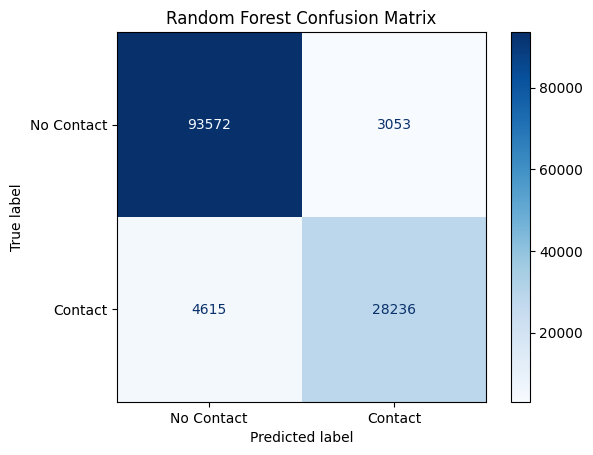


Confusion Matrix Percentages
----------------------------
True Negative Rate : 0.9684 (96.84%)
False Positive Rate: 0.0316 (3.16%)
Contact Detection Rate: 0.8595 (85.95%)
Miss Rate: 0.1405 (14.05%)

ROC AUC: 0.9761 (97.61%)


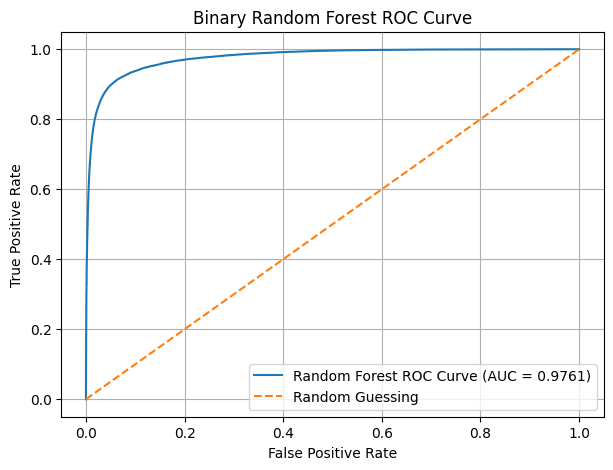

In [ ]:
# confusion matrix

matrix = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(matrix)

tn, fp, fn, tp = matrix.ravel()

print("\nConfusion Matrix Values")
print("-----------------------")
print(f"True Negatives : {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives : {tp}")

disp = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=["No Contact", "Contact"]
)

disp.plot(cmap=plt.cm.Blues)

plt.title("Random Forest Confusion Matrix")
plt.show()


# confusion matrix percentages

tn_rate = tn / (tn + fp)
fp_rate = fp / (tn + fp)

contact_detection_rate = tp / (tp + fn)
miss_rate = fn / (tp + fn)

print("\nConfusion Matrix Percentages")
print("----------------------------")
print(f"True Negative Rate : {tn_rate:.4f} ({tn_rate*100:.2f}%)")
print(f"False Positive Rate: {fp_rate:.4f} ({fp_rate*100:.2f}%)")
print(f"Contact Detection Rate: {contact_detection_rate:.4f} ({contact_detection_rate*100:.2f}%)")
print(f"Miss Rate: {miss_rate:.4f} ({miss_rate*100:.2f}%)")


# ROC AUC and curve

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

roc_auc = auc(fpr, tpr)

print(f"\nROC AUC: {roc_auc:.4f} ({roc_auc*100:.2f}%)")

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest ROC Curve (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    label="Random Guessing"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("Binary Random Forest ROC Curve")

plt.legend()

plt.grid(True)

plt.show()

Cross Validation and Feature Importance

In [ ]:
# cross validation

cv_scores = cross_val_score(rf_binary, X, y, cv=cv, scoring="f1")
print(f"Cross-Validation F1 Scores: {cv_scores}")
print(f"Mean F1 Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation of F1 Scores: {cv_scores.std():.4f}")

Cross-Validation F1 Scores: [0.87764057 0.87880144 0.88085801 0.87856532 0.87941194]
Mean F1 Score: 0.8791
Standard Deviation of F1 Scores: 0.0011


In [ ]:
importance = rf_binary.feature_importances_
importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": importance
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

print("\nFeature Importances:")
print(importance_df)


Feature Importances:
  Feature  Importance
6     R_7    0.190313
4     R_5    0.158077
2     R_3    0.128117
0     R_1    0.123581
1     R_2    0.120751
7     R_8    0.098752
5     R_6    0.095498
3     R_4    0.084911


Save Model

In [ ]:
joblib.dump(
    rf_binary,
    "binary_random_forest.pkl"
)

['binary_random_forest.pkl']